In [ ]:
# ==============================================================================
# 0. CONFIGURATION & IMPORTS
# ==============================================================================
# Note: This notebook requires the ProDy library.
# If not installed, uncomment and run:
# !pip install prody

import os
import re
import json
import time
import warnings
import requests
from io import StringIO
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# BioPython & ProDy
from Bio import SeqIO
from Bio.PDB import MMCIFParser, PDBIO, Select
import prody as pr

warnings.filterwarnings('ignore')
pr.confProDy(verbosity='none') 

# --- File Paths (Adjust relative to your environment) ---
# IMPORTANT: Ensure these files are present in your data directory
DATA_DIR = Path("../data/resources/") 
PDB_DIR = Path("../data/pdb_cif/") # Directory containing .cif files

PATH_PDB_CLASSIFY = DATA_DIR / 'GPCR_PDB_classify_v2.csv'
PATH_REP_CHAIN = DATA_DIR / 'Rep_GPCR_chain.csv'
PATH_GPCR_INFO = DATA_DIR / 'ChEMBL_GPCR_Info.csv'

# Output Paths
OUTPUT_DIR = Path("./results/prs_analysis/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Analysis Settings ---
FAMILY_MAP = {
    'Acetylcholine receptors (muscarinic)': 'Acetylcholine',
    '5-Hydroxytryptamine receptors': 'Serotonin',
    'Dopamine receptors': 'Dopamine',
    'Adenosine receptors': 'Adenosine',
    'Adrenoceptors': 'Adrenoceptors',
    'Cannabinoid receptors': 'Cannabinoid',
}

MOTIF_ORDER = [
    'DRY Motif', 
    'PIF Motif', 
    'CWxP Motif', 
    'NPxxY Motif', 
    'Flexible Loop/Terminus'
]

print("Configuration loaded.")

In [ ]:
# ==============================================================================
# 1. HELPER FUNCTIONS
# ==============================================================================

# --- BW Numbering Cache ---
BW_CACHE_FILE = Path("./bw_numbering_cache.json")

def load_bw_cache():
    if BW_CACHE_FILE.exists() and BW_CACHE_FILE.stat().st_size > 0:
        try:
            with open(BW_CACHE_FILE, 'r') as f:
                return json.load(f)
        except json.JSONDecodeError:
            return {}
    return {}

def save_bw_cache(cache):
    with open(BW_CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=4)

# --- API Helpers ---
def get_entry_name_from_uniprot_api(uniprot_ac):
    """Fetches UniProt Entry Name (e.g., ADRB2_HUMAN)."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_ac}.json"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json().get('uniProtkbId')
    except Exception:
        return None

def get_bw_map_from_api(entry_name):
    """Fetches BW map from GPCRdb."""
    if not entry_name: return None
    url = f"https://gpcrdb.org/services/residues/{entry_name.lower()}/"
    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
        residues = response.json()
        if residues:
            return {
                str(res['sequence_number']): res['display_generic_number']
                for res in residues if res.get('display_generic_number')
            }
    except Exception:
        return None

# --- Functional Region Mapping ---
def get_functional_region(bw_number):
    """Assigns a functional region label based on BW number."""
    if pd.isna(bw_number): return 'Flexible Loop/Terminus'
    
    try:
        bw_str = str(bw_number)
        if 'x' not in bw_str: return 'Flexible Loop/Terminus'
        
        generic_part = bw_str.split('x', 1)[0]
        if '.' not in generic_part: return 'Flexible Loop/Terminus'
        
        helix_str, pos_str = generic_part.split('.', 1)
        helix, pos = int(helix_str), int(pos_str)

        if helix == 3 and pos == 50: return 'DRY Motif'
        if helix == 5 and pos == 50: return 'PIF Motif'
        if helix == 6 and pos == 48: return 'CWxP Motif'
        if helix == 7 and pos == 53: return 'NPxxY Motif'
        if 1 <= helix <= 8: return 'Other (TM Residue)'
        
        return 'Flexible Loop/Terminus'
    except:
        return 'Flexible Loop/Terminus'

# --- PDB Filtering ---
class ChainSelect(Select):
    def __init__(self, chain_id): self.chain_id = chain_id
    def accept_chain(self, chain): return chain.id == self.chain_id
    def accept_residue(self, residue): return residue.get_id()[0] == ' '

In [ ]:
# ==============================================================================
# 2. PRS CALCULATION FUNCTION
# ==============================================================================
def calculate_prs_sensitivity(pdb_id, rep_chain_id, pdb_dir):
    """
    Loads CIF, builds ANM, and calculates PRS sensitivity profile.
    Returns: {pdb_resnum: sensitivity_score} or None
    """
    parser = MMCIFParser()
    pdb_path = pdb_dir / f"{pdb_id.lower()}.cif"
    temp_clean_file = f"temp_clean_{pdb_id}_{rep_chain_id}.pdb"
    
    if not pdb_path.exists():
        return None

    try:
        structure = parser.get_structure(pdb_id, str(pdb_path))
        io = PDBIO()
        io.set_structure(structure)
        io.save(temp_clean_file, ChainSelect(rep_chain_id))
        
        atoms = pr.parsePDB(temp_clean_file)
        if atoms is None: return None
        
        calphas = atoms.select(f'calpha and chain {rep_chain_id}')
        if not calphas: return None
        
        # ProDy ANM
        anm = pr.ANM(f'{pdb_id}_anm')
        anm.buildHessian(calphas, gamma=1.0, cutoff=15.0)
        anm.calcModes(n_modes=None)
        
        # PRS Calculation
        _, _, sensitivity = pr.calcPerturbResponse(anm)
        
        return dict(zip(calphas.getResnums(), sensitivity))
        
    except Exception as e:
        # print(f"PRS Failed for {pdb_id}: {e}")
        return None
    finally:
        if os.path.exists(temp_clean_file):
            os.remove(temp_clean_file)

In [ ]:
# ==============================================================================
# 3. MAIN ANALYSIS PIPELINE
# ==============================================================================

# A. Load Metadata
print("--- Loading Metadata ---")
try:
    df_classify = pd.read_csv(PATH_PDB_CLASSIFY).rename(columns={'Entry': 'UniProt_ID'})
    df_rep_chain = pd.read_csv(PATH_REP_CHAIN).sort_values('score', ascending=False).drop_duplicates(['UniProt_ID', 'PDB_ID'])
    df_gpcr_info = pd.read_csv(PATH_GPCR_INFO).rename(columns={'UniProt Accessions': 'UniProt_ID'})

    # Map Families & Filter
    df_gpcr_info['Family'] = df_gpcr_info['Receptor Family'].map(FAMILY_MAP)
    df_gpcr_info = df_gpcr_info.dropna(subset=['Family'])[['UniProt_ID', 'Family', 'Name']]

    # Merge
    df_meta = pd.merge(df_classify, df_rep_chain, on=['UniProt_ID', 'PDB_ID'])
    df_meta = pd.merge(df_meta, df_gpcr_info, on='UniProt_ID')

    # Filter States
    df_meta = df_meta[df_meta['Classification'].isin(['Apo', 'w agonist', 'w antagonist'])]
    df_meta['State'] = df_meta['Classification'].replace({'w agonist': 'Agonist', 'w antagonist': 'Antagonist'})
    
    print(f"PDBs to analyze: {len(df_meta)}")

except FileNotFoundError as e:
    print(f"Error loading metadata: {e}")
    # Stop execution here if data is missing
    raise

# B. Fetch BW Maps
print("--- Fetching BW Numbering Maps ---")
bw_map_cache = load_bw_cache()
all_bw_maps = {}
unique_ids = df_meta['UniProt_ID'].unique()
needs_saving = False

for uid in tqdm(unique_ids, desc="BW Maps"):
    if uid in bw_map_cache:
        all_bw_maps[uid] = bw_map_cache[uid]
        continue
    
    entry_name = get_entry_name_from_uniprot_api(uid)
    if entry_name:
        bw_map = get_bw_map_from_api(entry_name)
        if bw_map:
            all_bw_maps[uid] = bw_map
            bw_map_cache[uid] = bw_map
            needs_saving = True
            time.sleep(0.1)

if needs_saving: save_bw_cache(bw_map_cache)

# C. Run PRS Analysis
print("--- Running PRS Calculations ---")
results = []

for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="PRS"):
    uid, pdb, chain = row['UniProt_ID'], row['PDB_ID'], row['chain_id']
    
    if uid not in all_bw_maps: continue
    
    sensitivity = calculate_prs_sensitivity(pdb, chain, PDB_DIR)
    if not sensitivity: continue
    
    bw_map = all_bw_maps[uid]
    
    for resnum, score in sensitivity.items():
        bw_num = bw_map.get(str(resnum))
        region = get_functional_region(bw_num)
        
        results.append({
            'Family': row['Family'],
            'State': row['State'],
            'Region': region,
            'PRS_Sensitivity_Score': score,
            'PDB_ID': pdb,
            'UniProt_ID': uid
        })

print(f"Analysis complete. {len(results)} data points collected.")

--- [Step 6: Normalizing and Aggregating Results] ---
Calculating Percentile Ranks (this may take a moment)...
Aggregation complete.
          Family  GPCR Functional Region  Mean PRS Sensitivity
0  Acetylcholine              CWxP Motif              0.131578
1  Acetylcholine               DRY Motif              0.176923
2  Acetylcholine  Flexible Loop/Terminus              0.515245
3  Acetylcholine             NPxxY Motif              0.165338
4  Acetylcholine               PIF Motif              0.303114
--- [Step 7: Generating Final Plot] ---

✅ Plot saved to '/home/hyojin0912/Activity/Final/revision/analysis_results/PRS/PRS_Benchmark_Figure6_Style.png'
✅ Aggregated data saved to '/home/hyojin0912/Activity/Final/revision/analysis_results/PRS/PRS_Benchmark_Aggregated_Data.csv'
✅ Raw normalized data saved to '/home/hyojin0912/Activity/Final/revision/analysis_results/PRS/PRS_Benchmark_Raw_Normalized_Data.csv'


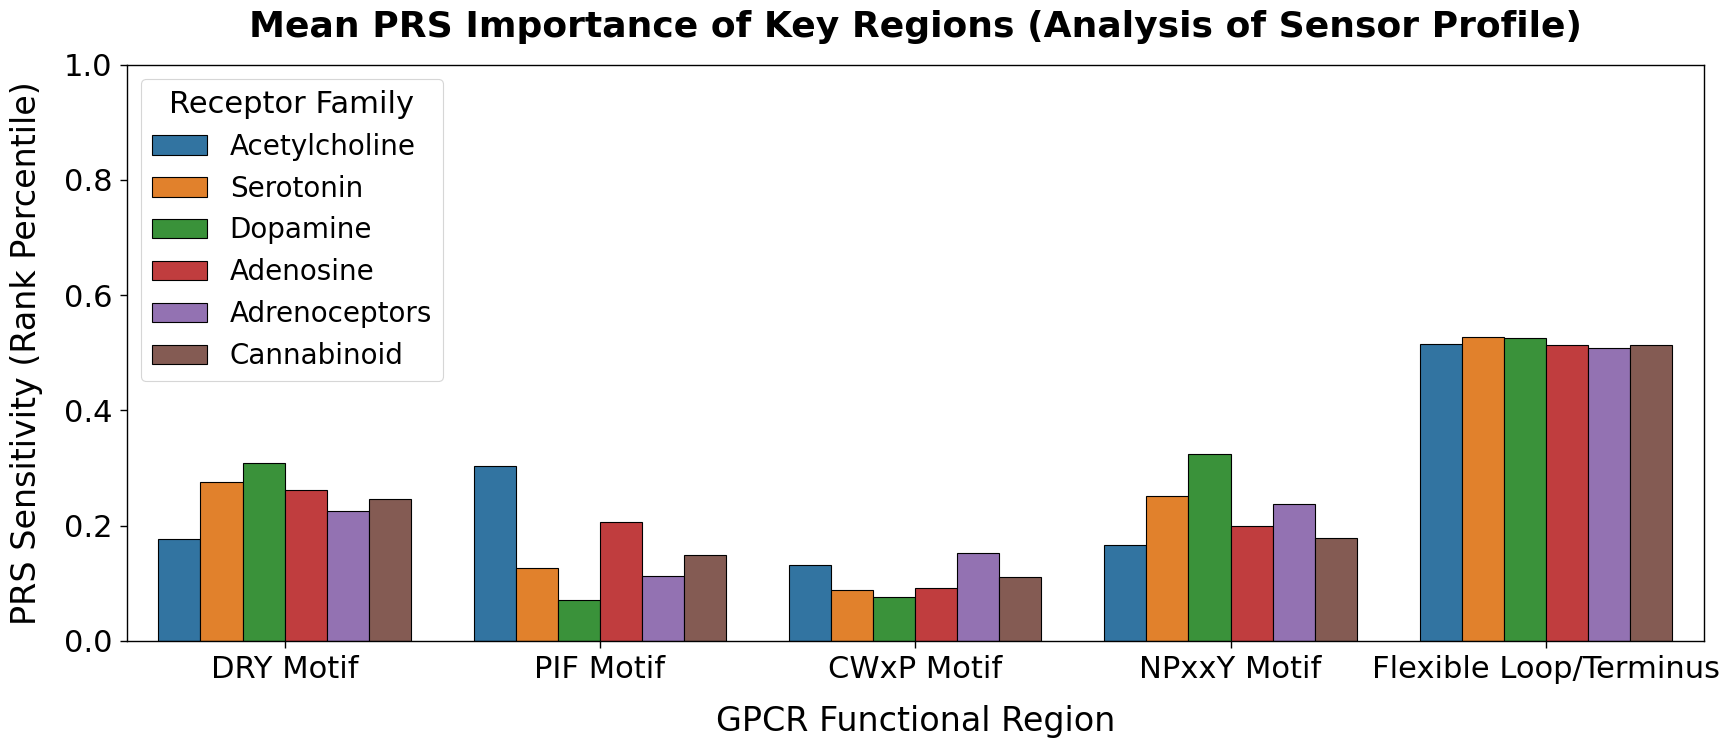

In [13]:
# ==============================================================================
# 4. VISUALIZATION
# ==============================================================================

if not results:
    print("No results to plot. Check PDB directory path.")
else:
    df_res = pd.DataFrame(results)
    
    # 1. Normalize (Rank Percentile per PDB)
    print("Normalizing scores...")
    df_res['PRS_Rank_Percentile'] = df_res.groupby('PDB_ID')['PRS_Sensitivity_Score'].rank(pct=True)
    
    # 2. Filter & Aggregate
    df_plot = df_res[df_res['Region'] != 'Other (TM Residue)']
    df_agg = df_plot.groupby(['Family', 'Region'])['PRS_Rank_Percentile'].mean().reset_index()

    # 3. Save Data
    df_agg.to_csv(OUTPUT_DIR / "PRS_Benchmark_Aggregated.csv", index=False)

    # 4. Plot: Mean PRS Sensitivity (Figure S11 equivalent)
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("paper", font_scale=1.5)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    hue_order = [f for f in FAMILY_MAP.values() if f in df_agg['Family'].unique()]
    
    sns.barplot(
        data=df_agg,
        x='Region', y='PRS_Rank_Percentile',
        hue='Family', hue_order=hue_order,
        order=MOTIF_ORDER,
        palette='tab10', edgecolor='black', ax=ax
    )
    
    ax.set_title('Mean PRS Sensitivity of Functional Regions (Sensor Profile)', fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Functional Region', fontsize=16)
    ax.set_ylabel('Mean Sensitivity (Rank Percentile)', fontsize=16)
    ax.set_ylim(0, 1.0)
    ax.legend(title='Family', loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "FigureS_PRS_Sensitivity.png", dpi=300)
    print("Figure S saved.")
    plt.show()

    # 5. Delta PRS Plot (Agonist - Antagonist)
    print("Generating Delta PRS Plot...")
    df_delta = df_res[df_res['State'].isin(['Agonist', 'Antagonist'])]
    df_delta_agg = df_delta.groupby(['Family', 'Region', 'State'])['PRS_Rank_Percentile'].mean().reset_index()
    
    # Pivot to calculate delta
    df_pivot = df_delta_agg.pivot_table(index=['Family', 'Region'], columns='State', values='PRS_Rank_Percentile').reset_index()
    df_pivot = df_pivot.fillna(0)
    df_pivot['Delta_PRS'] = df_pivot['Agonist'] - df_pivot['Antagonist']
    
    fig2, ax2 = plt.subplots(figsize=(16, 8))
    sns.barplot(
        data=df_pivot,
        x='Region', y='Delta_PRS',
        hue='Family', hue_order=hue_order,
        order=MOTIF_ORDER,
        palette='tab10', edgecolor='black', ax=ax2
    )
    
    ax2.set_title('ΔPRS (Agonist – Antagonist) Across Functional Motifs', fontsize=18, fontweight='bold', pad=15)
    ax2.set_xlabel('Functional Region', fontsize=16)
    ax2.set_ylabel('ΔPRS (Mean Rank Percentile)', fontsize=16)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.legend(title='Family', loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "FigureS_Delta_PRS.png", dpi=300)
    print("Figure S saved.")
    plt.show()